## Data Modeling
This notebook includes the data modeling steps in the solar energy project. <br>
As inputs it requires the cleaned, encoded, re-sampled and scaled data frames X_train, X_test, y_train, y_test. <br>
The objective is to test and optimize different models.

### 0. Data collection

In [ ]:
import pandas as pd
path = r"..\data\processed\\"

X_train = pd.read_csv(path+'X_train_os_robust.csv')
X_test = pd.read_csv(path+'X_test_robust.csv')
y_train = pd.read_csv(path+'y_train_os.csv')
y_test = pd.read_csv(path+'y_test.csv')

print(X_train.shape,y_train.shape)
X_train.head(1)

(6064, 11) (6064, 1)


,Acres,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,Urban or Rural,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
0,-0.112907,0.183598,-0.288115,-0.22065,0.916364,0.0,2.0,1.0,1.0,0.0,1.0


### 1. Random Forest Classifier

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instantiating the model (e.g., RandomForestClassifier) and train the model on the scaled training data (y_train does not need to be scaled since it is binary)
model = RandomForestClassifier(random_state=42)
y_train = y_train.values.ravel() # to prevent warning messages
model.fit(X_train, y_train)

# Create predictions
y_pred = model.predict(X_test)

# Evaluate model performance using a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       322
           1       0.94      0.94      0.94       758

    accuracy                           0.92      1080
   macro avg       0.90      0.90      0.90      1080
weighted avg       0.92      0.92      0.92      1080



### 2. SVM Classifier

In [7]:
from sklearn.svm import SVC

# Instantiate the model and train it
svm_model=SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Create predictions
svm_pred = svm_model.predict(X_test)
svm_train_pred = svm_model.predict(X_train)

# Evaluate model performance using a classification report
svm_report = classification_report(y_test, svm_pred)
print("Classification Report:")
print(svm_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       322
           1       0.96      0.89      0.92       758

    accuracy                           0.90      1080
   macro avg       0.87      0.90      0.88      1080
weighted avg       0.91      0.90      0.90      1080



### 3. XGBoost Classifier

In [26]:
from xgboost import XGBClassifier

# Instantiate the model and train it
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Create predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate model performance using a classification report
xgb_report = classification_report(y_test, xgb_pred)
print("Classification Report:")
print(xgb_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       322
           1       0.92      0.95      0.93       758

    accuracy                           0.91      1080
   macro avg       0.89      0.88      0.89      1080
weighted avg       0.91      0.91      0.91      1080



### 4. K-Nearest Neighbors Classifier

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the model and train it
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Create predictions
knn_pred = knn_model.predict(X_test)

# Evaluate model performance using a classification report
knn_report = classification_report(y_test, knn_pred)
print("Classification Report:")
print(knn_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       322
           1       0.96      0.91      0.93       758

    accuracy                           0.91      1080
   macro avg       0.88      0.91      0.89      1080
weighted avg       0.91      0.91      0.91      1080



### 5. GridsearchCV

In [29]:
# Grid Search with Cross Validation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

param_grids = {
    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "KNN": KNeighborsClassifier()
}

scorer = make_scorer(f1_score, average='binary')
best_models = {}

for name, model in models.items():
    print(f" Tuning {name} for F1-score...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring=scorer, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f" Best {name} Params: {grid_search.best_params_}")
    print(f" Best {name} F1-score: {grid_search.best_score_:.4f}\n")

# Evaluate the best models on the test set
print("Final Model Evaluations on Test Data:")
for name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    f1 = f1_score(y_train, y_train_pred)
    print(f" {name} train: F1-score = {f1:.4f}")
    y_test_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_test_pred)
    print(f" {name} test: F1-score = {f1:.4f}")

 Tuning RandomForest for F1-score...
 Best RandomForest Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
 Best RandomForest F1-score: 0.9566

 Tuning SVM for F1-score...
 Best SVM Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
 Best SVM F1-score: 0.9147

 Tuning XGBoost for F1-score...
 Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
 Best XGBoost F1-score: 0.9543

 Tuning KNN for F1-score...
 Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
 Best KNN F1-score: 0.9438

Final Model Evaluations on Test Data:
 RandomForest train: F1-score = 1.0000
 RandomForest test: F1-score = 0.9426
 SVM train: F1-score = 0.9291
 SVM test: F1-score = 0.9382
 XGBoost train: F1-score = 0.9998
 XGBoost test: F1-score = 0.9334
 KNN train: F1-score = 1.0000
 KNN test: F1-score = 0.9325


In [30]:
print("We decided for the SVC model with its best parameters ({'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}) because it has the lowest overfitting.")

We decided for the SVC model with its best parameters ({'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}) because it has the lowest overfitting.


### 6. SVC model with best parameters

In [8]:
svm_model = SVC(C = 10, gamma = 'auto', kernel = 'rbf', probability = True, random_state=42)
svm_model.fit(X_train, y_train)

# Create predictions
y_pred = svm_model.predict(X_test)
y_train_pred = svm_model.predict(X_train)

# Evaluate model performance using a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       322
           1       0.96      0.92      0.94       758

    accuracy                           0.91      1080
   macro avg       0.89      0.91      0.90      1080
weighted avg       0.92      0.91      0.92      1080



In [9]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_test=confusion_matrix(y_test, y_pred)
cm_train=confusion_matrix(y_train, y_train_pred)

print('Confusion matrix for test set')
print(cm_test)

print('Confusion matrix for train set')
print(cm_train)

Confusion matrix for test set
[[290  32]
 [ 60 698]]
Confusion matrix for train set
[[2845  187]
 [ 239 2793]]


In [11]:
# F1-score
from sklearn.metrics import f1_score

f1_score_test=f1_score(y_test, y_pred)
f1_score_train=f1_score(y_train, y_train_pred)

print('f1_score_test =',f1_score_test)
print('f1_score_train =',f1_score_train)

f1_score_test = 0.9381720430107526
f1_score_train = 0.9291417165668664


### 7. ROC curve and SHAP plot

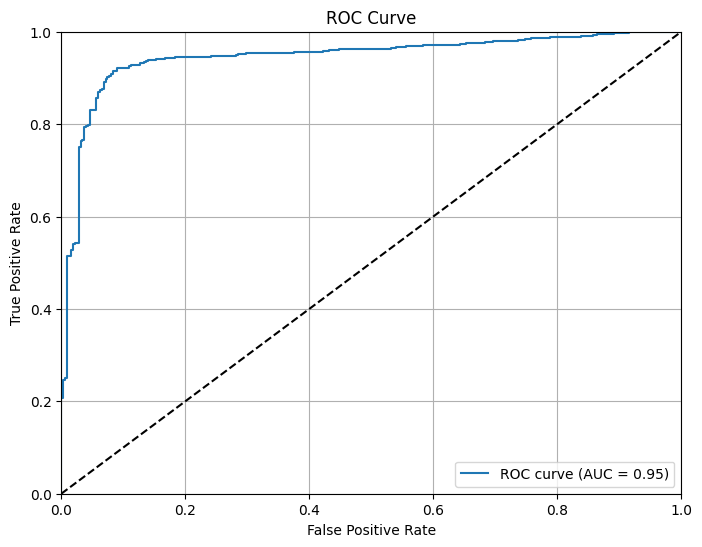

In [12]:
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score, roc_curve

# ROC Curve Plot for the SVC model
y_pred_proba_test = svm_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Computing SHAP values...


  0%|          | 0/1080 [00:00<?, ?it/s]

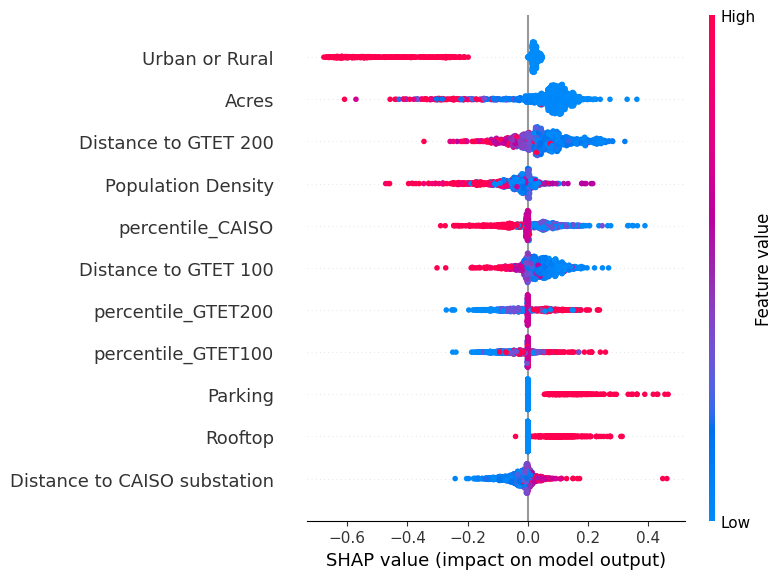

In [13]:
# SHAP Analysis for the SVC model (skip for testing because it takes approx. 45 minutes)
print("\nComputing SHAP values...")

# Use K-means clustering to reduce the number of background samples
background_data = shap.kmeans(X_train, 10) # reduce to 1 to fasten the process

# Create the SHAP explainer with the reduced background data
explainer = shap.KernelExplainer(svm_model.predict_proba, background_data)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot (for model interpretability)
shap.summary_plot(shap_values[1], X_test) # For class 1